In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "output"

df = pd.read_csv(DATA_DIR / "analysis_data.csv")

print("Rows:", len(df))
print("Countries:", df["Entity"].nunique())
print("Years:", df["Year"].min(), "-", df["Year"].max())

Rows: 1092
Countries: 52
Years: 2000 - 2021


In [19]:
features = [
    "resource_rents",
    "log_gdp_pc",
    "electricity_access",
    "Year"
]

target = "water_access"

In [20]:
train = df[df["Year"] <= 2017].copy()
test = df[df["Year"] >= 2018].copy()

print("Training observations:", len(train))
print("Test observations:", len(test))

print("Training years:", train["Year"].min(), "-", train["Year"].max())
print("Test years:", test["Year"].min(), "-", test["Year"].max())

Training observations: 888
Test observations: 204
Training years: 2000 - 2017
Test years: 2018 - 2021


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train[features])
X_test_scaled = scaler.transform(test[features])

X_train = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=train.index
)

X_test = pd.DataFrame(
    X_test_scaled,
    columns=features,
    index=test.index
)

y_train = train[target]
y_test = test[target]

display(X_train.head())

,resource_rents,log_gdp_pc,electricity_access,Year
0,1.268350,1.160344,1.913709,-1.683823
1,1.005423,1.177965,1.913709,-1.490640
2,0.991656,1.221710,1.913709,-1.297457
3,1.076092,1.277024,1.913709,-1.104274
4,1.222786,1.310485,1.913709,-0.911092


In [22]:
X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test, has_constant="add")

ols = sm.OLS(
    y_train,
    X_train_ols
).fit(cov_type="HC1")

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:           water_access   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                     669.8
Date:                Sun, 30 Aug 2026   Prob (F-statistic):          1.18e-265
Time:                        22:14:49   Log-Likelihood:                -3258.0
No. Observations:                 888   AIC:                             6526.
Df Residuals:                     883   BIC:                             6550.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 64.1765      0

In [23]:
results = pd.DataFrame({
    "coefficient": ols.params,
    "ci_low": ols.conf_int()[0],
    "ci_high": ols.conf_int()[1],
    "p_value": ols.pvalues
})

display(results)

,coefficient,ci_low,ci_high,p_value
const,64.176473,63.550696,64.802250,0.000000e+00
resource_rents,-2.626776,-3.348315,-1.905237,9.658495e-13
log_gdp_pc,3.563778,2.260165,4.867391,8.410630e-08
electricity_access,11.858660,10.715696,13.001625,6.263038e-92
Year,1.000032,0.348322,1.651742,2.633958e-03


In [24]:
train_pred = ols.predict(X_train_ols)
test_pred = ols.predict(X_test_ols)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

print("OLS PERFORMANCE")
print("----------------")
print("Train R²:", round(train_r2, 3))
print("Test R²:", round(test_r2, 3))
print("Train RMSE:", round(train_rmse, 2))
print("Test RMSE:", round(test_rmse, 2))

OLS PERFORMANCE
----------------
Train R²: 0.726
Test R²: 0.68
Train RMSE: 9.49
Test RMSE: 8.87


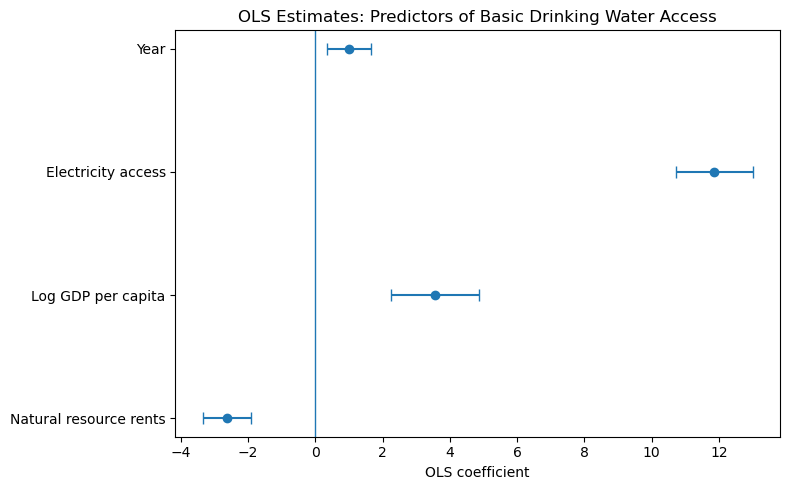

In [25]:
plot_results = results.drop(index="const").copy()

labels = {
    "resource_rents": "Natural resource rents",
    "log_gdp_pc": "Log GDP per capita",
    "electricity_access": "Electricity access",
    "Year": "Year"
}

plot_results["label"] = plot_results.index.map(labels)

x = plot_results["coefficient"]
lower_error = x - plot_results["ci_low"]
upper_error = plot_results["ci_high"] - x

plt.figure(figsize=(8, 5))

plt.errorbar(
    x,
    plot_results["label"],
    xerr=[lower_error, upper_error],
    fmt="o",
    capsize=4
)

plt.axvline(0, linewidth=1)

plt.xlabel("OLS coefficient")
plt.ylabel("")
plt.title("OLS Estimates: Predictors of Basic Drinking Water Access")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "OLSEstimate_Burkina.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
results.to_csv(
    OUTPUT_DIR / "ols_coefficients.csv"
)

performance = pd.DataFrame({
    "model": ["OLS"],
    "train_r2": [train_r2],
    "test_r2": [test_r2],
    "train_rmse": [train_rmse],
    "test_rmse": [test_rmse]
})

performance.to_csv(
    OUTPUT_DIR / "ols_performance.csv",
    index=False
)

display(performance)

,model,train_r2,test_r2,train_rmse,test_rmse
0,OLS,0.72556,0.679732,9.487506,8.86751
